# Student Placement Prediction Using Logistic Regression

## Introduction

This project focuses on predicting whether a student will get placed or not based on different academic and personal factors.

This is a **classification problem** because the target variable has two possible outcomes:

- **1 → Placed**
- **0 → Not Placed**

To solve this problem, I use **Logistic Regression**, a supervised machine learning algorithm commonly used for binary classification problems.

The model learns patterns from the given student data and predicts the probability of a student getting placed.

## Objective

The main objective of this project is to build a machine learning classification model that can predict whether a student will get placed based on the available features.

The project follows the basic machine learning workflow:

- Understanding the dataset
- Exploratory Data Analysis (EDA)
- Data preprocessing
- Splitting the data into training and testing sets
- Training a Logistic Regression classification model
- Making predictions
- Evaluating the model's performance

In [ ]:
import numpy as np

In [ ]:
import pandas as pd

## Dataset

The dataset contains information about students and their placement outcomes.

The features are used as inputs to the machine learning model, while the placement status is used as the target variable.

The target variable is:

**Placement:** Whether the student was placed or not.

In [ ]:
path = "/dataset/placement.csv"

In [ ]:
data = pd.read_csv(path)

In [ ]:
data

,Unnamed: 0,cgpa,iq,placement
0,0,6.8,123.0,1
1,1,5.9,106.0,0
2,2,5.3,121.0,0
3,3,7.4,132.0,1
4,4,5.8,142.0,0
...,...,...,...,...
95,95,4.3,200.0,0
96,96,4.4,42.0,0
97,97,6.7,182.0,1
98,98,6.3,103.0,1


In [ ]:
data.head()

,Unnamed: 0,cgpa,iq,placement
0,0,6.8,123.0,1
1,1,5.9,106.0,0
2,2,5.3,121.0,0
3,3,7.4,132.0,1
4,4,5.8,142.0,0


In [ ]:
data.shape

(100, 4)

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  100 non-null    int64  
 1   cgpa        100 non-null    float64
 2   iq          100 non-null    float64
 3   placement   100 non-null    int64  
dtypes: float64(2), int64(2)
memory usage: 3.3 KB


In [ ]:
## lets remove the unnnecessary column
data = data.iloc[:,1:]

In [ ]:
data.head()

,cgpa,iq,placement
0,6.8,123.0,1
1,5.9,106.0,0
2,5.3,121.0,0
3,7.4,132.0,1
4,5.8,142.0,0


In [ ]:
import matplotlib.pyplot as plt


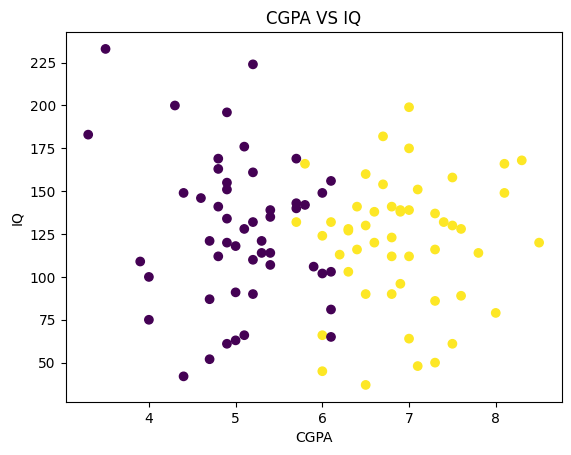

In [ ]:
plt.scatter(data['cgpa'],data['iq'],c=data['placement'])
plt.title("CGPA VS IQ")
plt.xlabel('CGPA')
plt.ylabel('IQ')
plt.show()

Now the important goal is to make the ML model understand the hidden pattern from this data.We use logistic regression.

In [ ]:
X = data.iloc[:,0:2]
y = data.iloc[:,-1]

In [ ]:
X

,cgpa,iq
0,6.8,123.0
1,5.9,106.0
2,5.3,121.0
3,7.4,132.0
4,5.8,142.0
...,...,...
95,4.3,200.0
96,4.4,42.0
97,6.7,182.0
98,6.3,103.0


In [ ]:
y

,placement
0,1
1,0
2,0
3,1
4,0
...,...
95,0
96,0
97,1
98,1


In [ ]:
## lets train test split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size = 0.1)


In [ ]:
X_train

,cgpa,iq
29,7.0,112.0
66,6.9,96.0
9,5.1,66.0
57,6.5,130.0
93,6.8,112.0
...,...,...
0,6.8,123.0
51,4.8,141.0
7,5.0,63.0
78,6.1,81.0


In [ ]:
X_test

,cgpa,iq
69,8.5,120.0
42,7.6,89.0
8,6.1,156.0
32,7.0,139.0
5,7.1,48.0
89,4.9,151.0
84,5.7,169.0
68,4.0,75.0
70,6.3,127.0
91,7.5,158.0


In [ ]:
y_train

,placement
29,1
66,1
9,0
57,1
93,1
...,...
0,1
51,0
7,0
78,0


In [ ]:
y_test

,placement
69,1
42,1
8,0
32,1
5,1
89,0
84,0
68,0
70,1
91,1


In [ ]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()


In [ ]:
X_train = scaler.fit_transform(X_train)
X_train

array([[ 0.9587633 , -0.29118597],
       [ 0.86850316, -0.69205385],
       [-0.75617943, -1.44368112],
       [ 0.50746259,  0.15979039],
       [ 0.77824302, -0.29118597],
       [-0.93669971, -0.09075203],
       [-0.66591928,  2.51488917],
       [-0.75617943,  0.10968191],
       [ 0.77824302,  0.43538706],
       [ 1.95162488,  0.635821  ],
       [ 1.68084445, -0.24107749],
       [-0.57565914, -0.06569779],
       [ 1.22954373, -0.94259627],
       [ 0.9587633 ,  1.2872313 ],
       [ 0.9587633 , -1.49378961],
       [-0.03409828, -0.44151143],
       [-1.83930115, -0.3663487 ],
       [-0.84643957, -0.81732506],
       [-1.02695986,  0.98658039],
       [ 0.50746259, -0.84237931],
       [-0.66591928,  0.9364719 ],
       [ 0.3269423 , -0.51667415],
       [ 0.14642201,  0.20989888],
       [ 0.05616187,  0.635821  ],
       [-0.48539899,  0.38527857],
       [ 1.41006402, -1.56895233],
       [-0.12435842,  1.06174312],
       [-1.20748014,  0.56065827],
       [ 0.41720244,

In [ ]:
X_test = scaler.transform(X_test)
X_test

array([[  8.5, 120. ],
       [  7.6,  89. ],
       [  6.1, 156. ],
       [  7. , 139. ],
       [  7.1,  48. ],
       [  4.9, 151. ],
       [  5.7, 169. ],
       [  4. ,  75. ],
       [  6.3, 127. ],
       [  7.5, 158. ]])

## About Logistic Regression

Logistic Regression is a supervised machine learning algorithm mainly used for classification problems.

In this project, the target variable represents two possible outcomes:

- 1 → Student is placed
- 0 → Student is not placed

The Logistic Regression model learns the relationship between the input features and the placement outcome and then predicts the probability of a student being placed.

In [ ]:
### lets use the logistic regression
from sklearn.linear_model import LogisticRegression
model = LogisticRegression()

In [ ]:
model.fit(X_train, y_train)

LogisticRegression()

In [ ]:
y_pred = model.predict(X_test)
y_pred

array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1])

In [ ]:
y_test

,placement
69,1
42,1
8,0
32,1
5,1
89,0
84,0
68,0
70,1
91,1


In [ ]:
from sklearn.metrics import accuracy_score


In [ ]:
accuracy_score(y_test, y_pred)

0.6

In [ ]:
from mlxtend.plotting import plot_decision_regions

<Axes: >

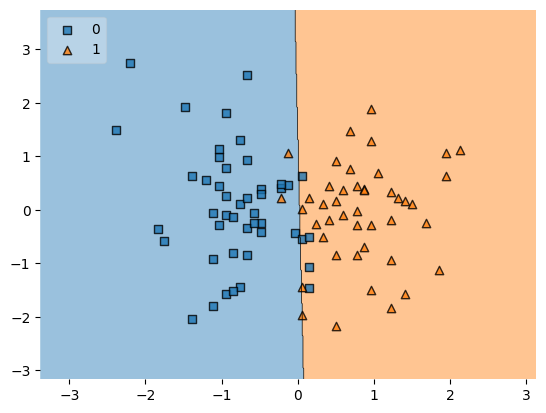

In [ ]:
plot_decision_regions(X_train, y_train.values, clf=model, legend=2)

In [ ]:
import pickle

In [ ]:
pickle.dump(model,open('model.pkl','wb'))

## Conclusion

In this project, I built a Logistic Regression model to predict whether a student will be placed or not.

The project helped me understand the basic workflow of a machine learning classification problem, including data preprocessing, exploratory data analysis, model training, prediction, and evaluation.

This is a beginner-level project that demonstrates how Logistic Regression can be applied to a real-world student placement prediction problem.